## 0. Configuración Inicial e Ingesta

Importación de librerías, carga del dataset y preparación de variables derivadas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_pickle('../Data/df_clean.pkl')
df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,is_promotion,competitor_pricing,seasonality,is_epidemic,demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [3]:
df.dtypes

date                  datetime64[ns]
store_id                    category
product_id                    object
category                    category
region                      category
inventory_level                int64
units_sold                     int64
units_ordered                  int64
price                        float64
discount                       int64
weather_condition           category
is_promotion                category
competitor_pricing           float64
seasonality                 category
is_epidemic                 category
demand                         int64
dtype: object

In [4]:
# Agregar features 

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.day_name().astype('category')
df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,is_promotion,competitor_pricing,seasonality,is_epidemic,demand,year,month,day,day_of_week
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday


In [5]:
# Analisis de variables categoricas y numericas

df_cat = df.select_dtypes(exclude=['number'])
df_num = df.select_dtypes(include=['number'])

print(f"Variables categóricas: {list(df_cat.columns)}")
print(f"Forma: {df_cat.shape}")

print(f"Variables numéricas: {list(df_num.columns)}")
print(f"Forma: {df_num.shape}")

Variables categóricas: ['date', 'store_id', 'product_id', 'category', 'region', 'weather_condition', 'is_promotion', 'seasonality', 'is_epidemic', 'day_of_week']
Forma: (76000, 10)
Variables numéricas: ['inventory_level', 'units_sold', 'units_ordered', 'price', 'discount', 'competitor_pricing', 'demand', 'year', 'month', 'day']
Forma: (76000, 10)


## I. Análisis Univariado

Examinación del comportamiento individual de cada variable del conjunto de datos.

### 1.1 Análisis Numérico — Distribución y Varianza

Estadísticos descriptivos, asimetría y curtosis. Boxplots e histogramas de cada variable numérica.

In [6]:
desc = df_num.describe().T
desc['skewness'] = df_num.skew()
desc['kurtosis'] = df_num.kurt()
desc

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
inventory_level,76000.0,301.062842,226.510161,0.00,136.0000,227.0,408.0000,2267.00,1.591938,3.371711
units_sold,76000.0,88.827316,43.994525,0.00,58.0000,84.0,114.0000,426.00,0.790429,1.249067
units_ordered,76000.0,89.090645,162.404627,0.00,0.0000,0.0,121.0000,1616.00,2.515878,7.305801
price,76000.0,67.726028,39.377899,4.74,31.9975,64.5,95.8300,228.03,0.485025,-0.483944
discount,76000.0,9.087039,7.475781,0.00,5.0000,10.0,10.0000,25.00,0.643149,-0.405212
competitor_pricing,76000.0,69.454029,40.943818,4.29,32.6200,65.7,97.9325,261.22,0.549003,-0.309692
demand,76000.0,104.317158,46.964801,4.00,71.0000,100.0,133.0000,430.00,0.607778,0.674937
year,76000.0,2022.559211,0.570479,2022.00,2022.0000,2023.0,2023.0000,2024.00,0.405098,-0.779282
month,76000.0,6.307895,3.546325,1.00,3.0000,6.0,9.0000,12.00,0.026178,-1.244793
day,76000.0,15.711842,8.790894,1.00,8.0000,16.0,23.0000,31.00,0.007328,-1.193357


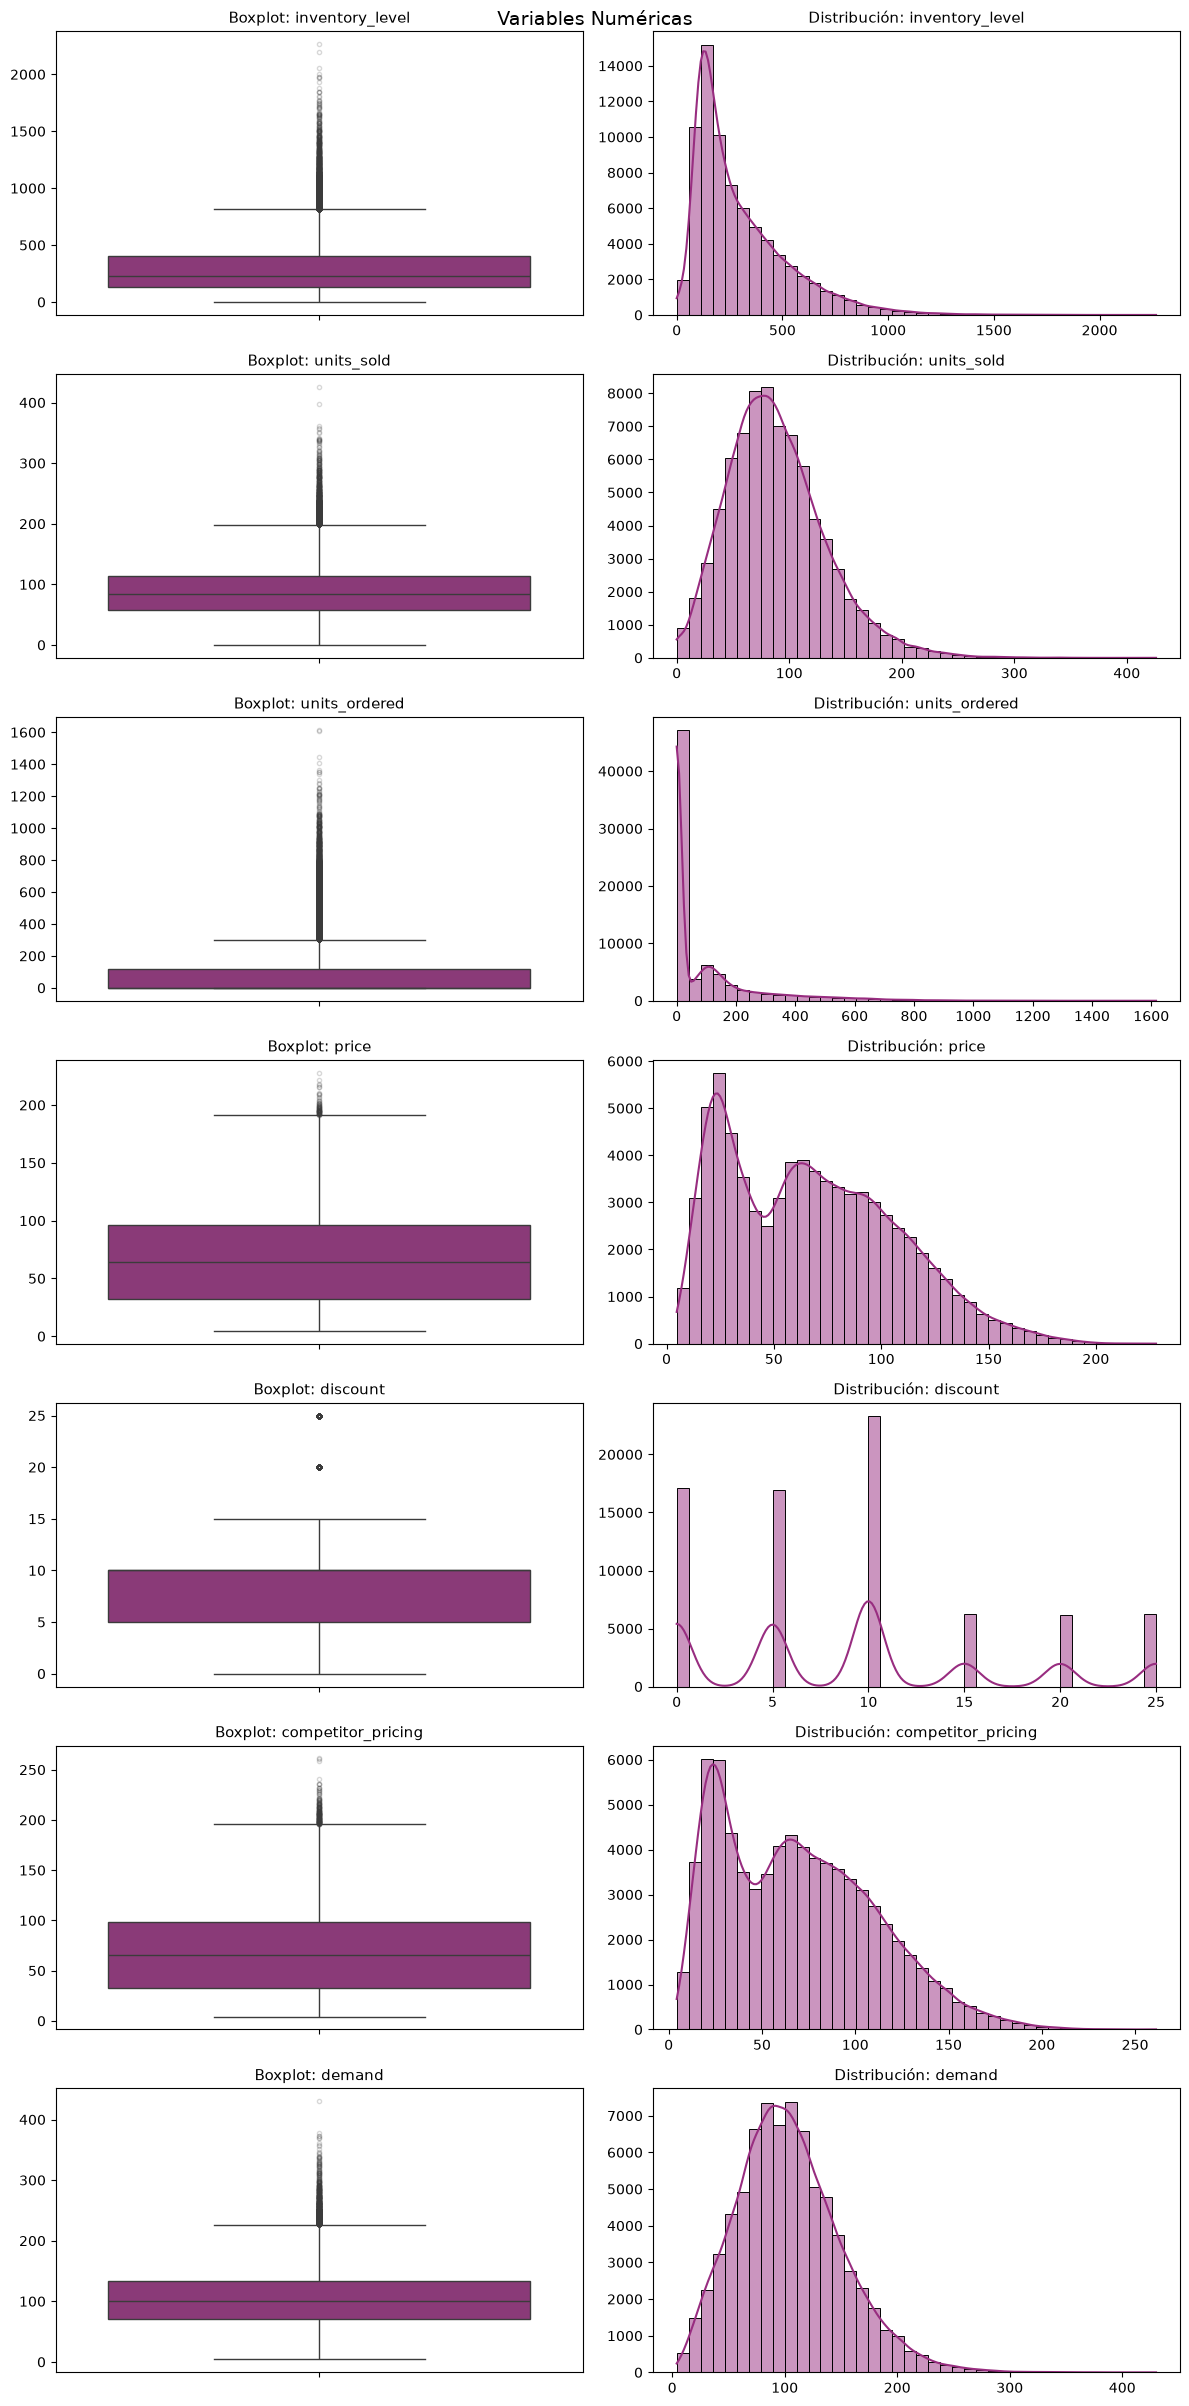

In [7]:
columnas_num = [col for col in df_num.columns if col not in ['year', 'month', 'day']]

fig, axes = plt.subplots(nrows=len(columnas_num), ncols=2,
                          figsize=(12, 3.5 * len(columnas_num)))

for i, col in enumerate(columnas_num):
    color = sns.color_palette('magma')[2]

    sns.boxplot(data=df_num, y=col, ax=axes[i, 0], color=color,
                flierprops={'marker': 'o', 'alpha': 0.2, 'markersize': 3})
    axes[i, 0].set_title(f'Boxplot: {col}', fontsize=11)
    axes[i, 0].set(xlabel='', ylabel='')

    sns.histplot(data=df_num, x=col, bins=40, kde=True,
                 ax=axes[i, 1], color=color)
    axes[i, 1].set_title(f'Distribución: {col}', fontsize=11)
    axes[i, 1].set(xlabel='', ylabel='')

plt.suptitle('Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

### 1.2 Análisis Categórico — Frecuencias y Volúmenes

Frecuencia absoluta de cada clase en las variables categóricas. Permite entender el peso relativo de cada categoría en el histórico.

In [8]:
df_cat.columns

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'weather_condition', 'is_promotion', 'seasonality', 'is_epidemic',
       'day_of_week'],
      dtype='object')

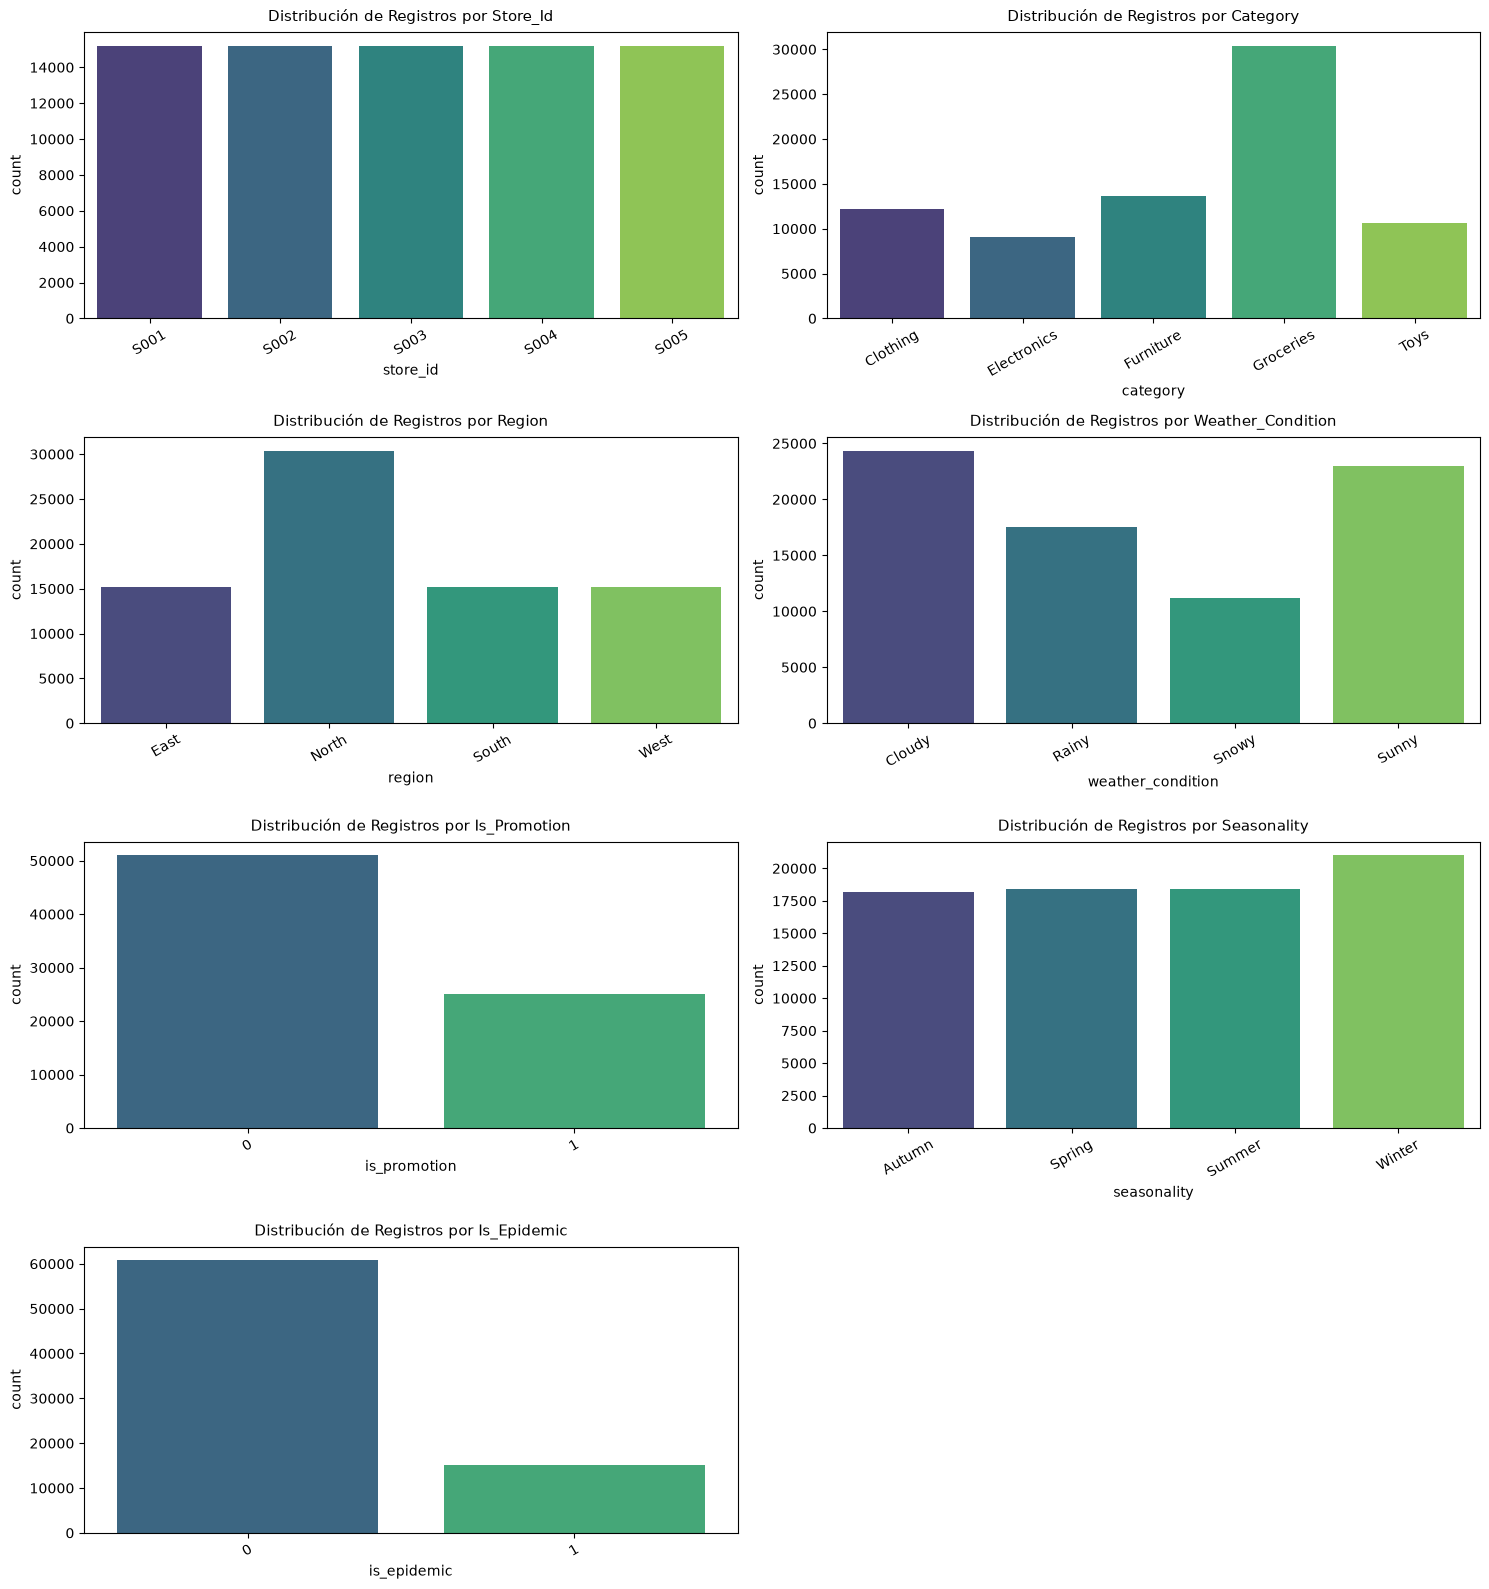

In [9]:
columnas_cat = [col for col in df_cat.columns if col not in ['date', 'product_id']]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 16))

for i, col in enumerate(columnas_cat):
    df_counts = df_cat[col].value_counts().reset_index()
    sns.barplot(data=df_counts, x=col, y='count', hue=col, palette='viridis', dodge=False, ax=axes[i // 2, i % 2], legend=False)
    axes[i // 2, i % 2].set_title(f'Distribución de Registros por {col.title()}', fontsize=11, pad=8)
    axes[i // 2, i % 2].set(ylabel='count')
    axes[i // 2, i % 2].tick_params(axis='x', rotation=30)

fig.delaxes(axes[3, 1])

plt.tight_layout()
plt.show()

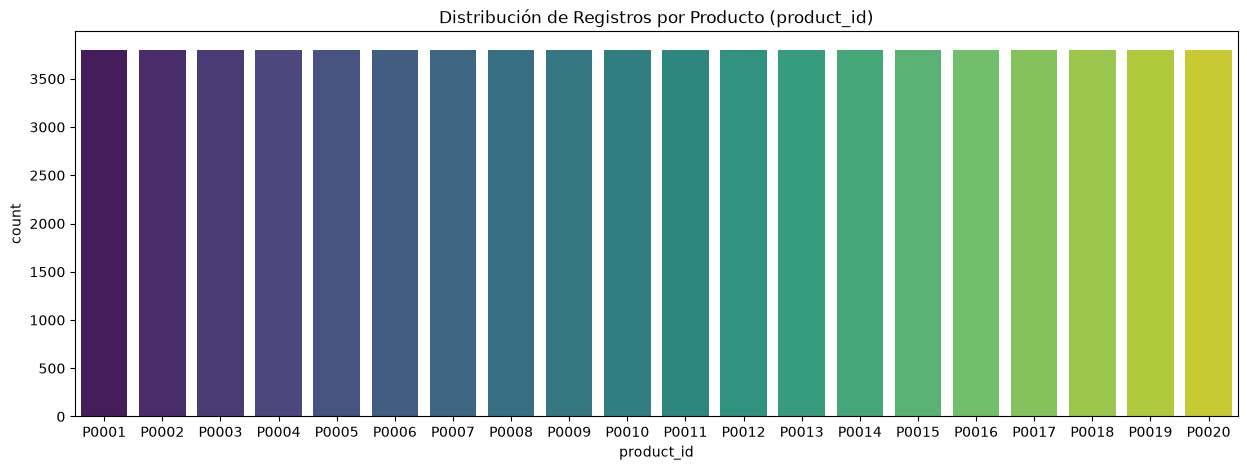

In [10]:
fig, ax = plt.subplots(figsize=(15,5))
sns.barplot(data=df_cat['product_id'].value_counts().reset_index(), x='product_id', y='count', hue='product_id', palette='viridis', dodge = False)
plt.title('Distribución de Registros por Producto (product_id)')
plt.show()

## II. Análisis Bivariado

### 2.1 Crosstabs — Distribución condicional

Proporción de cada fila normalizada a 1. Permite detectar si una categoría
condiciona la distribución de otra.

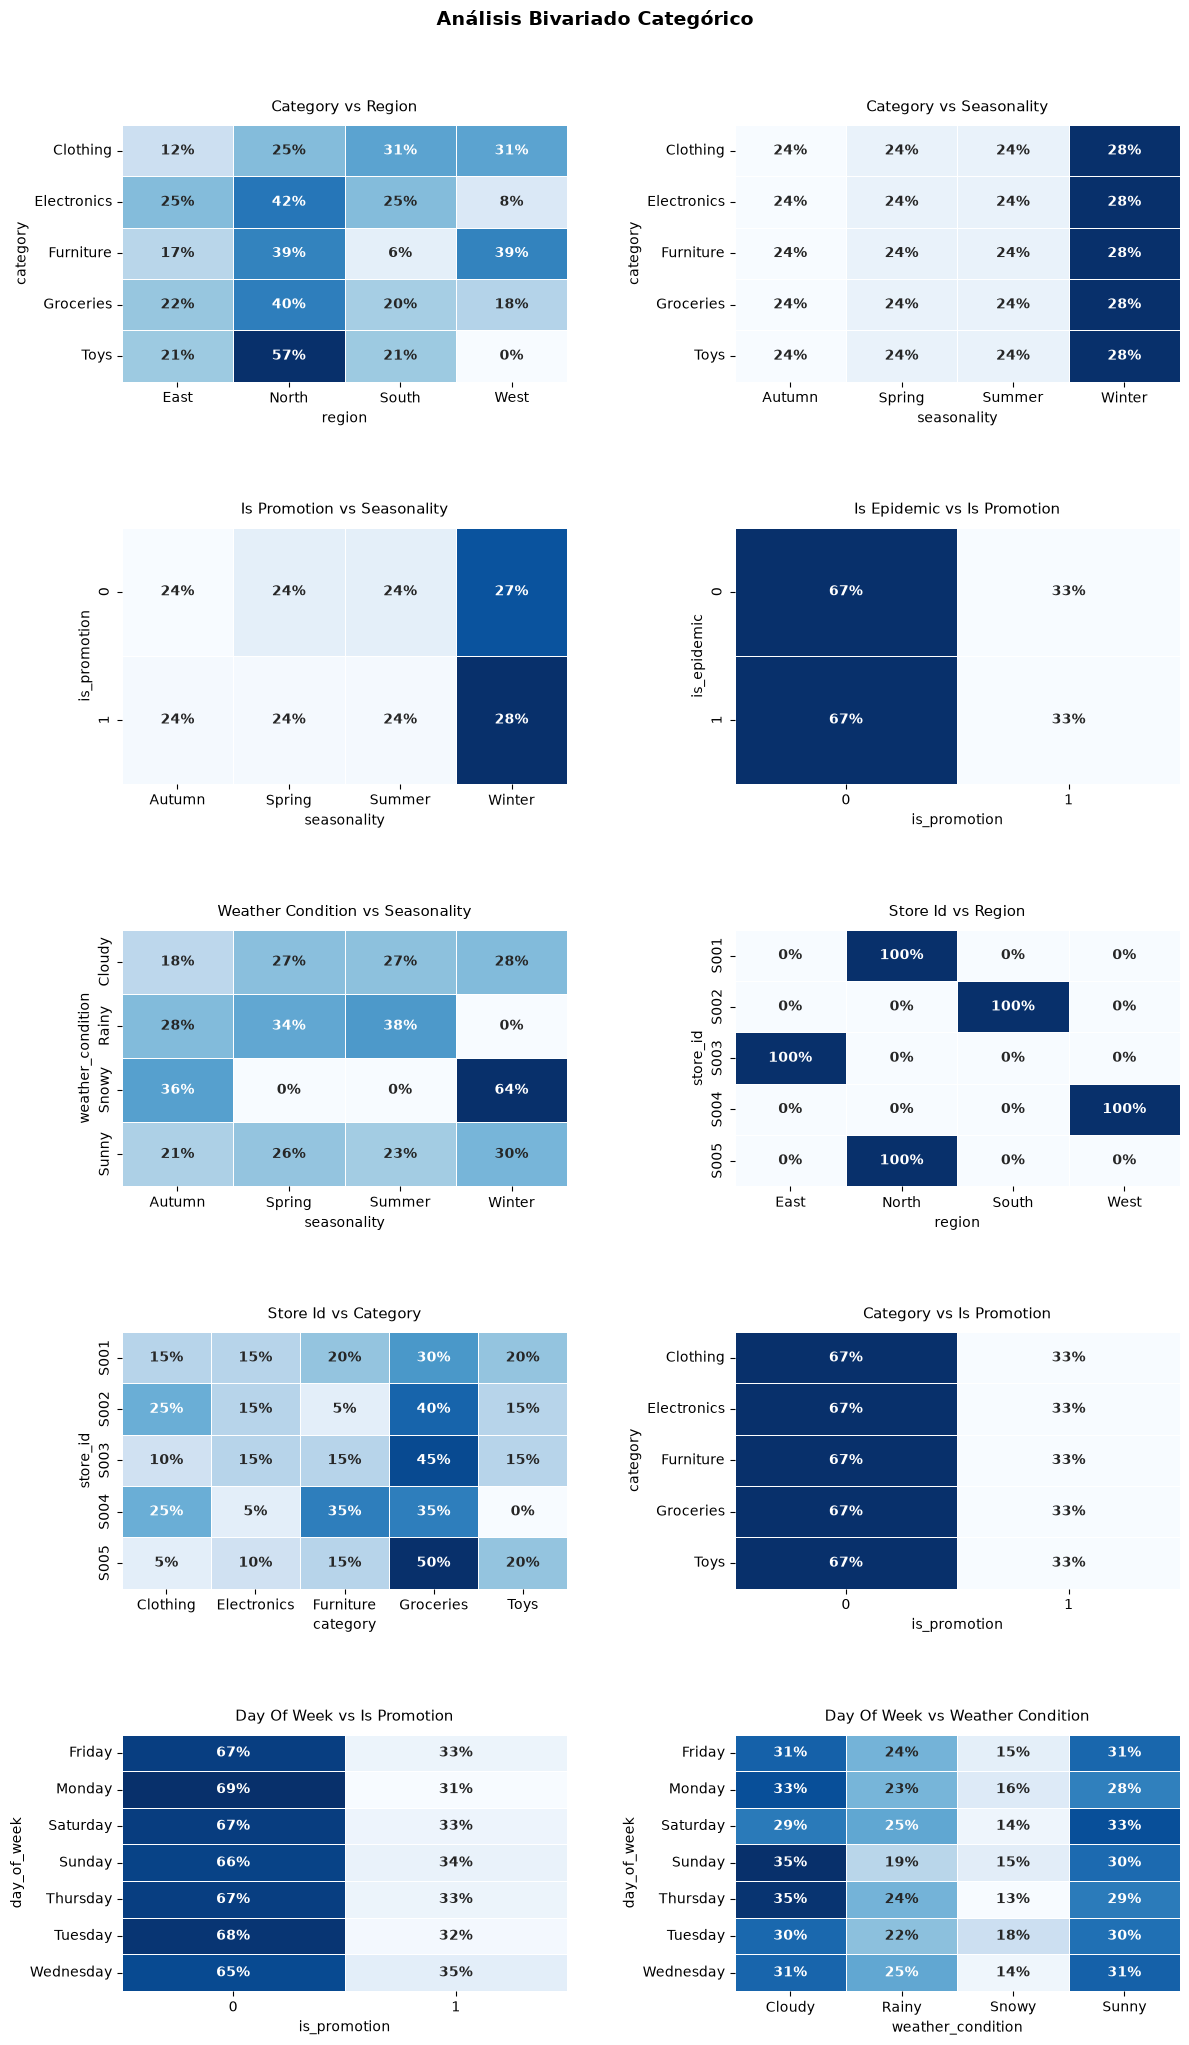

In [11]:
pares = [
    ("category", "region"),
    ("category", "seasonality"),
    ("is_promotion", "seasonality"),
    ("is_epidemic", "is_promotion"),
    ("weather_condition", "seasonality"),
    ("store_id", "region"),
    ("store_id", "category"),  
    ("category", "is_promotion"),  
    ("day_of_week", "is_promotion"),  
    ("day_of_week", "weather_condition"),  
]
validos = [(c1, c2) for c1, c2 in pares if c1 in df.columns and c2 in df.columns]

# Lienzo
fig, axes = plt.subplots( nrows=(len(validos) + 1) // 2, ncols=2, figsize=(12, 4 * ((len(validos) + 1) // 2)) )
axes = np.array(axes).flatten()

# Bucle para dibujar los heatmaps
for i, (c1, c2) in enumerate(validos):
    ct = pd.crosstab(df[c1], df[c2], normalize="index")

    sns.heatmap(ct, annot=True, fmt=".0%",
        cmap="Blues", cbar=False, linewidths=0.5,
        ax=axes[i], annot_kws={"weight": "bold"},
    )

    axes[i].set_title(  f"{c1.replace('_', ' ').title()} vs {c2.replace('_', ' ').title()}", fontsize=11, pad=10,)
    axes[i].set(xlabel=c2, ylabel=c1)

# Limpieza 
for j in range(len(validos), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle( "Análisis Bivariado Categórico", fontsize=14, weight="bold", y=1.02,)
plt.tight_layout(h_pad=5.5, w_pad=4.0)
plt.show()

### 2.2 Análisis Numérico vs. Numérico — Correlaciones e Identificación de Líderes

Matriz de correlación lineal entre variables numéricas. Scatter plots de demanda frente a predictores continuos. Identificación de productos líderes por precio y demanda total acumulada.

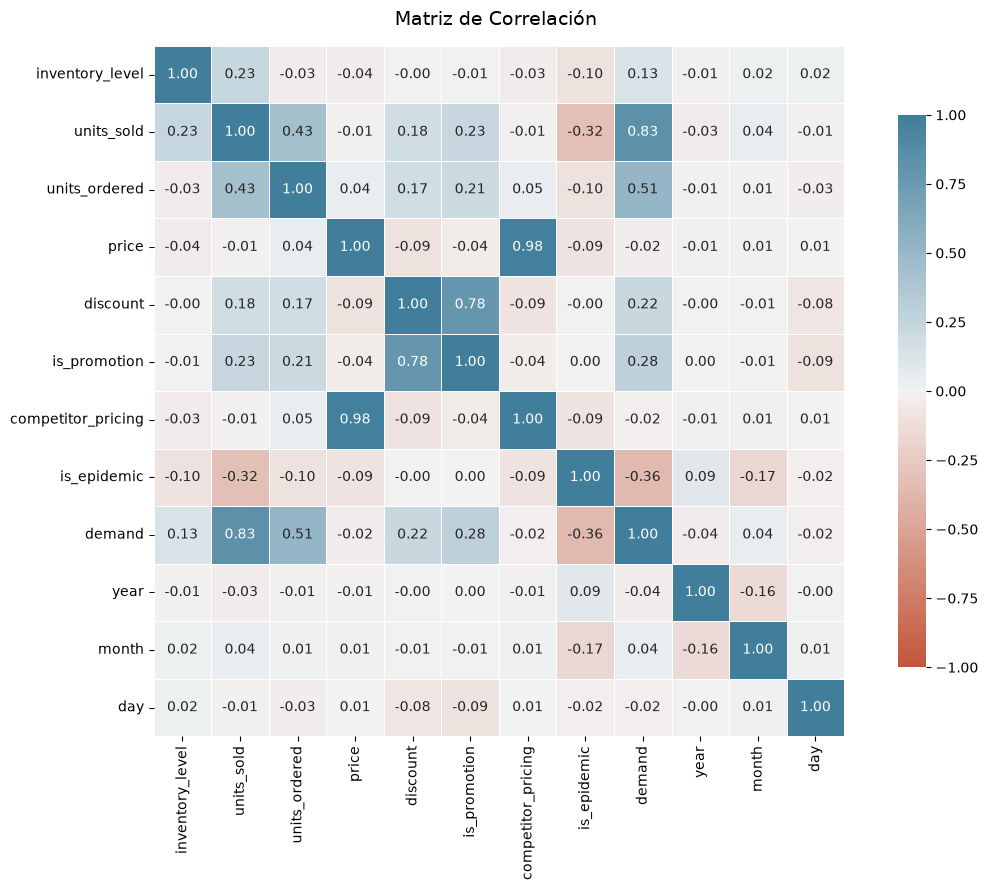

In [12]:
df_corr = df.copy()
df_corr['is_promotion'] = df_corr['is_promotion'].cat.codes
df_corr['is_epidemic'] = df_corr['is_epidemic'].cat.codes

corr_matrix = df_corr.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    annot=True,
    fmt='.2f',
    square=True,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Matriz de Correlación ', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


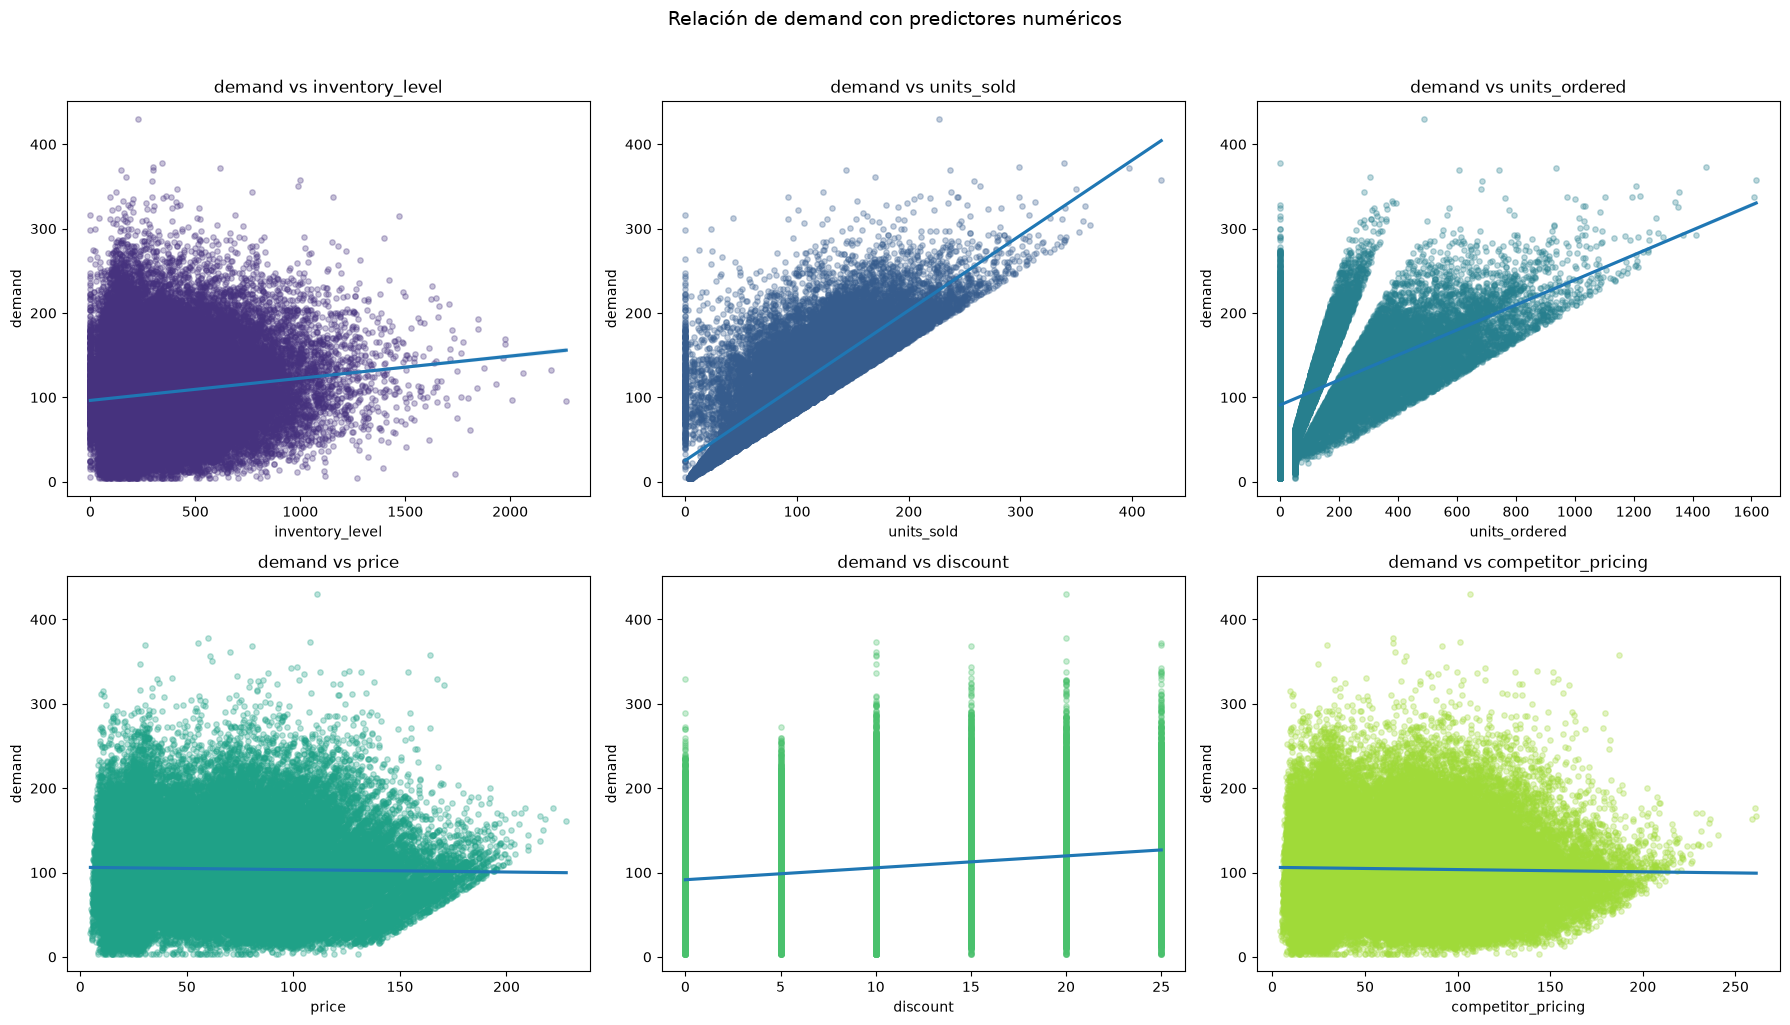

In [13]:
predictores_num = [c for c in df_num.columns if c not in ['demand', 'year', 'month', 'day']]
colores = sns.color_palette("viridis", 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col, color in zip(axes.flatten(), predictores_num, colores):
    sns.regplot(
        data=df_num, x=col, y='demand', ax=ax,
        scatter_kws={'alpha': 0.3, 's': 15, 'color': color}
    )
    ax.set_title(f'demand vs {col}')

plt.suptitle('Relación de demand con predictores numéricos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Producto con MAYOR demanda total: P0009 (demanda=450,324, precio=83.05)
Producto con MAYOR precio promedio: P0014 (precio=118.60, demanda=450,324)


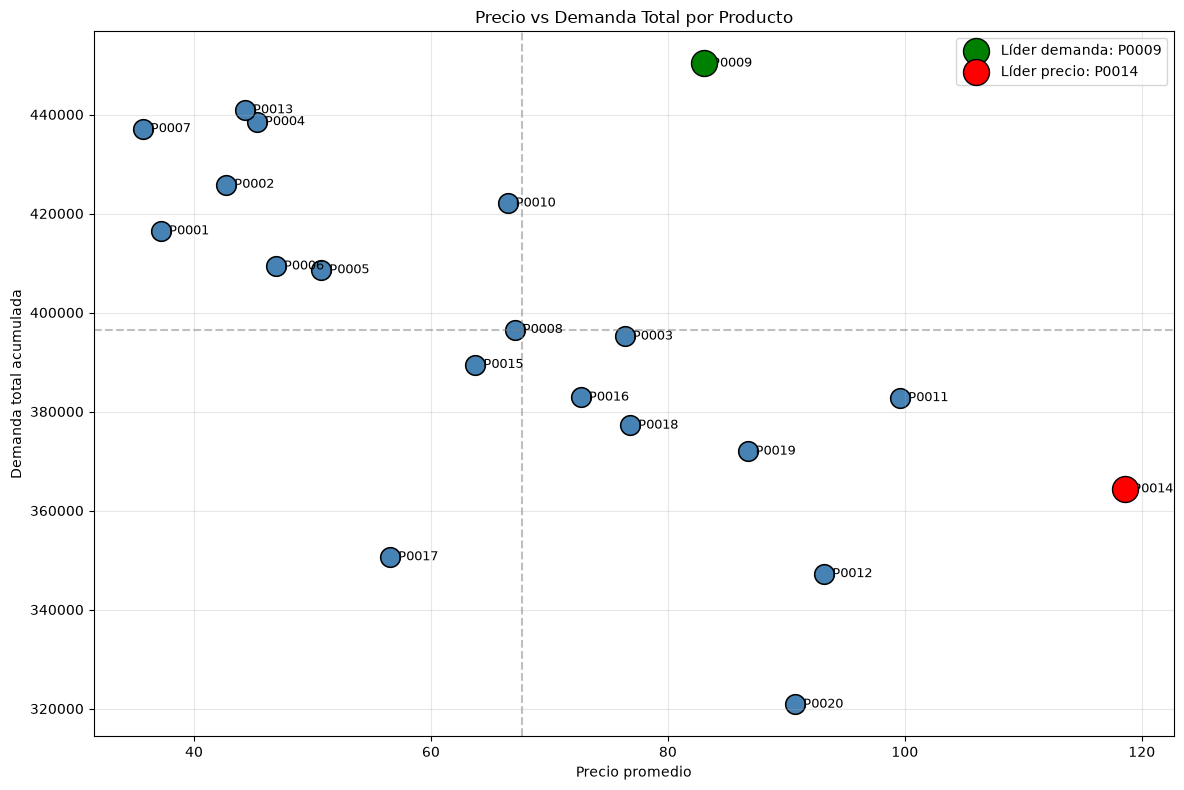

In [14]:
resumen_prod = df.groupby('product_id').agg(precio_promedio=('price', 'mean'), demanda_promedio=('demand', 'mean'), demanda_total=('demand', 'sum')).reset_index()

lider_demanda = resumen_prod.loc[resumen_prod['demanda_total'].idxmax()]
lider_precio = resumen_prod.loc[resumen_prod['precio_promedio'].idxmax()]

print(f"Producto con MAYOR demanda total: {lider_demanda['product_id']} (demanda={lider_demanda['demanda_total']:,.0f}, precio={lider_demanda['precio_promedio']:.2f})")
print(f"Producto con MAYOR precio promedio: {lider_precio['product_id']} (precio={lider_precio['precio_promedio']:.2f}, demanda={lider_demanda['demanda_total']:,.0f})")

fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(data=resumen_prod, x='precio_promedio', y='demanda_total', s=200, color='steelblue', edgecolor='black', ax=ax)
ax.scatter(lider_demanda['precio_promedio'], lider_demanda['demanda_total'], s=350, color='green', edgecolor='black', label=f"Líder demanda: {lider_demanda['product_id']}", zorder=5)
ax.scatter(lider_precio['precio_promedio'], lider_precio['demanda_total'], s=350, color='red', edgecolor='black', label=f"Líder precio: {lider_precio['product_id']}", zorder=5)

for _, row in resumen_prod.iterrows():
    ax.text(row['precio_promedio'], row['demanda_total'], f"  {row['product_id']}", fontsize=9, va='center')

ax.axvline(resumen_prod['precio_promedio'].mean(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(resumen_prod['demanda_total'].mean(), color='gray', linestyle='--', alpha=0.5)

ax.set(title='Precio vs Demanda Total por Producto', xlabel='Precio promedio', ylabel='Demanda total acumulada')
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

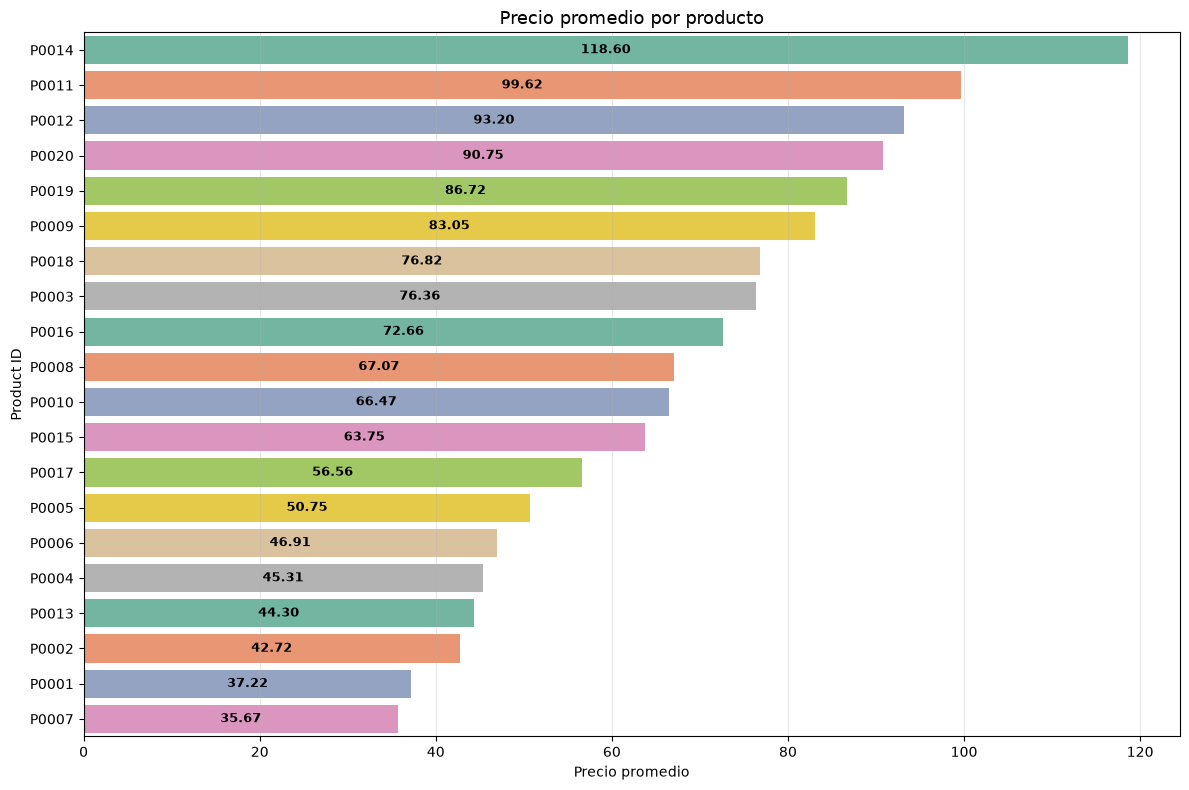

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))

precio_promedio = (df.groupby('product_id')['price']
                   .mean().sort_values(ascending=False))

sns.barplot(x=precio_promedio.values, y=precio_promedio.index,
            hue=precio_promedio.index, palette='Set2', legend=False, ax=ax)

ax.set_title('Precio promedio por producto', fontsize=13)
ax.set_xlabel('Precio promedio')
ax.set_ylabel('Product ID')
ax.grid(axis='x', alpha=0.3)

for i, val in enumerate(precio_promedio.values):
    ax.text(val / 2, i, f'{val:.2f}',
            va='center', ha='center',
            fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

### 2.3 Análisis Mixto — Predictores Categóricos vs. Target `demand`

Distribución de la demanda desagregada por cada variable categórica. Permite identificar qué categorías impulsan o deprimen la demanda.

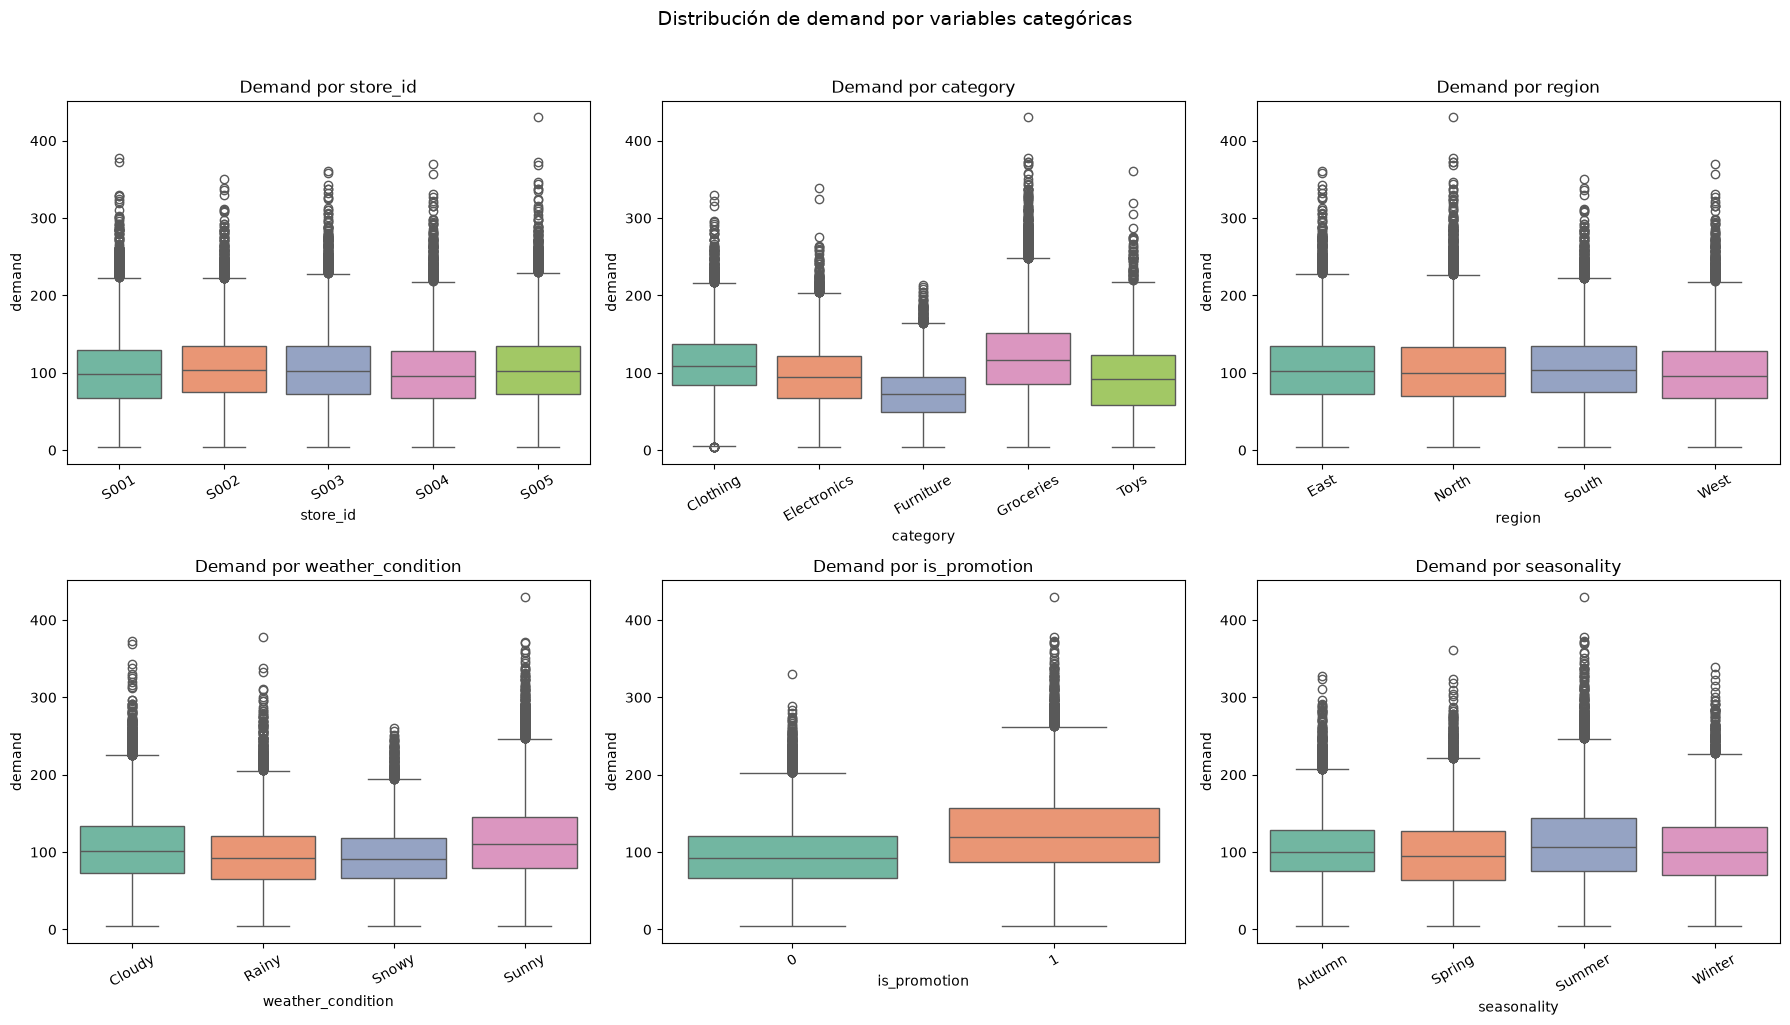

In [16]:
predictores_cat = [c for c in df_cat.columns if c not in ['day_of_week', 'date', 'product_id']]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), predictores_cat):
    sns.boxplot(
        data=df, x=col, y='demand', ax=ax,
        hue=col, palette='Set2', legend=False, dodge=False
    )
    ax.set_title(f'Demand por {col}')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribución de demand por variables categóricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Diego\AppData\Local\Temp\ipykernel_19016\3431041577.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_cat = df.groupby('category').agg(precio_promedio=('price', 'mean'), demanda_promedio=('demand', 'mean'), demanda_total=('demand', 'sum')).sort_values('demanda_total', ascending=False)


             precio_promedio  demanda_promedio  demanda_total
category                                                     
Groceries              51.66            120.98        3677684
Clothing               71.52            112.62        1369456
Furniture             121.51             73.58        1006590
Toys                   26.91             92.61         985338
Electronics            83.17             97.48         889036


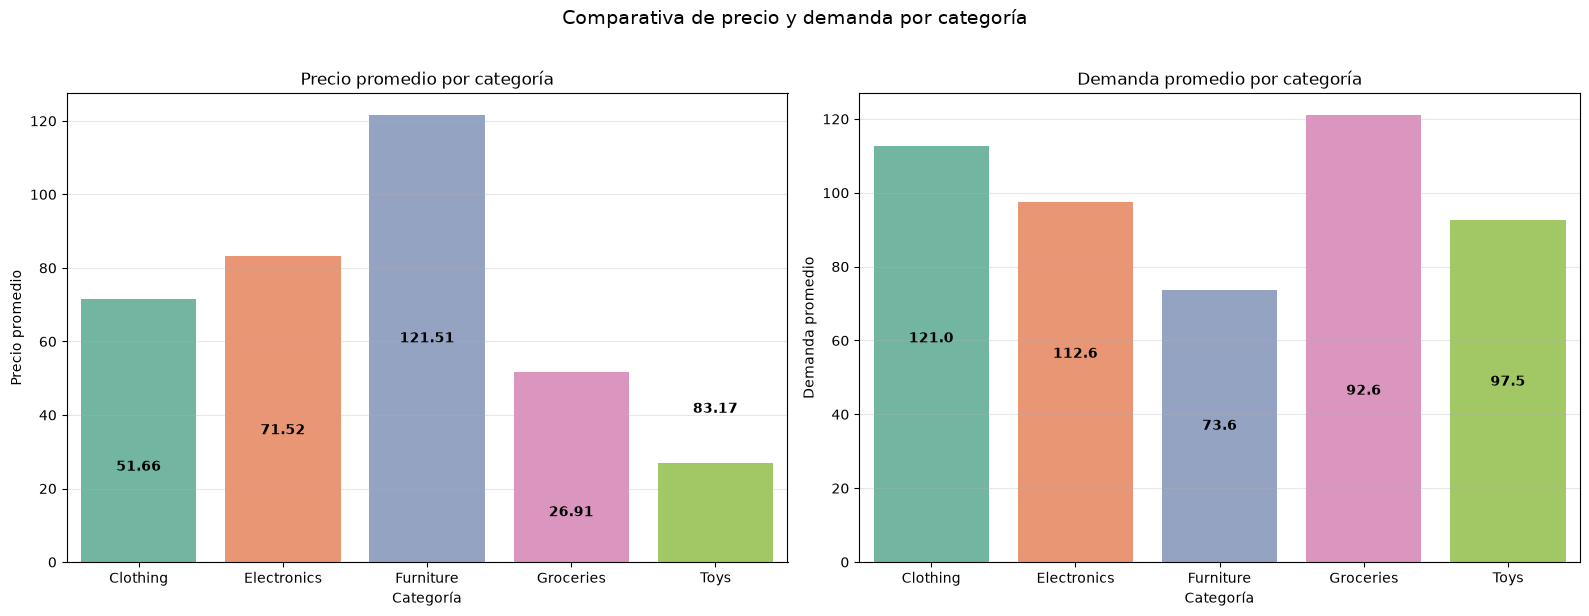

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

resumen_cat = df.groupby('category').agg(precio_promedio=('price', 'mean'), demanda_promedio=('demand', 'mean'), demanda_total=('demand', 'sum')).sort_values('demanda_total', ascending=False)
print(resumen_cat.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=resumen_cat, x=resumen_cat.index, y='precio_promedio', hue=resumen_cat.index, palette='Set2', legend=False, ax=axes[0], dodge=False)
axes[0].set(title='Precio promedio por categoría', xlabel='Categoría', ylabel='Precio promedio')
axes[0].grid(axis='y', alpha=0.3)
for i, val in enumerate(resumen_cat['precio_promedio']):
    axes[0].text(i, val / 2, f'{val:.2f}', ha='center', va='center', fontsize=10, fontweight='bold')

sns.barplot(data=resumen_cat, x=resumen_cat.index, y='demanda_promedio', hue=resumen_cat.index, palette='Set2', legend=False, ax=axes[1], dodge=False)
axes[1].set(title='Demanda promedio por categoría', xlabel='Categoría', ylabel='Demanda promedio')
axes[1].grid(axis='y', alpha=0.3)
for i, val in enumerate(resumen_cat['demanda_promedio']):
    axes[1].text(i, val / 2, f'{val:.1f}', ha='center', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Comparativa de precio y demanda por categoría', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

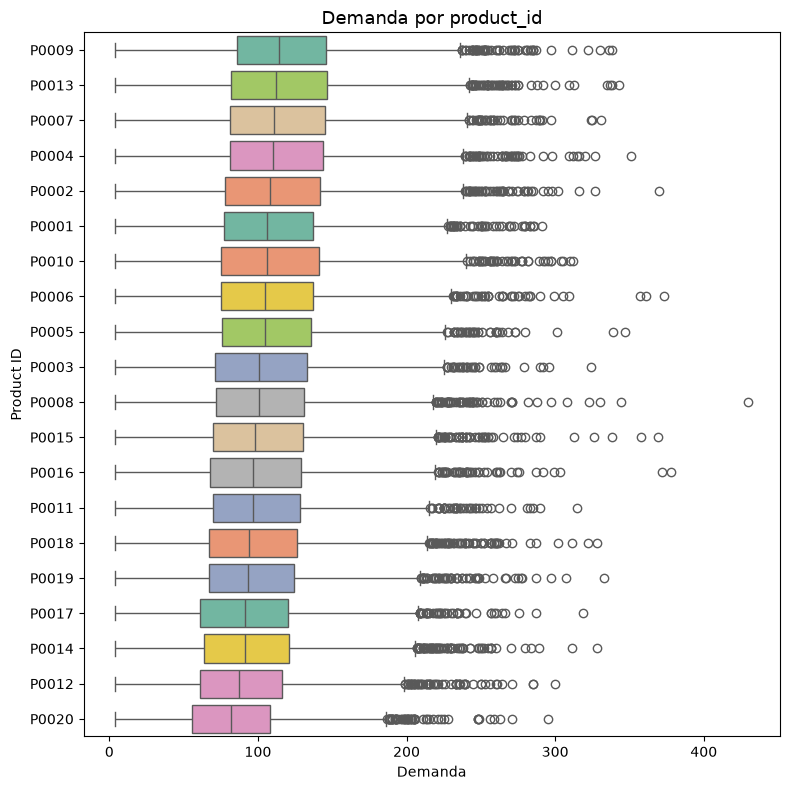

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.boxplot(
    data=df, x='demand', y='product_id', ax=ax,
    hue='product_id', palette='Set2', legend=False,
    order=df.groupby('product_id')['demand'].median().sort_values(ascending=False).index
)
ax.set_title('Demanda por product_id', fontsize=13)
ax.set_xlabel('Demanda')
ax.set_ylabel('Product ID')
plt.tight_layout()
plt.show()

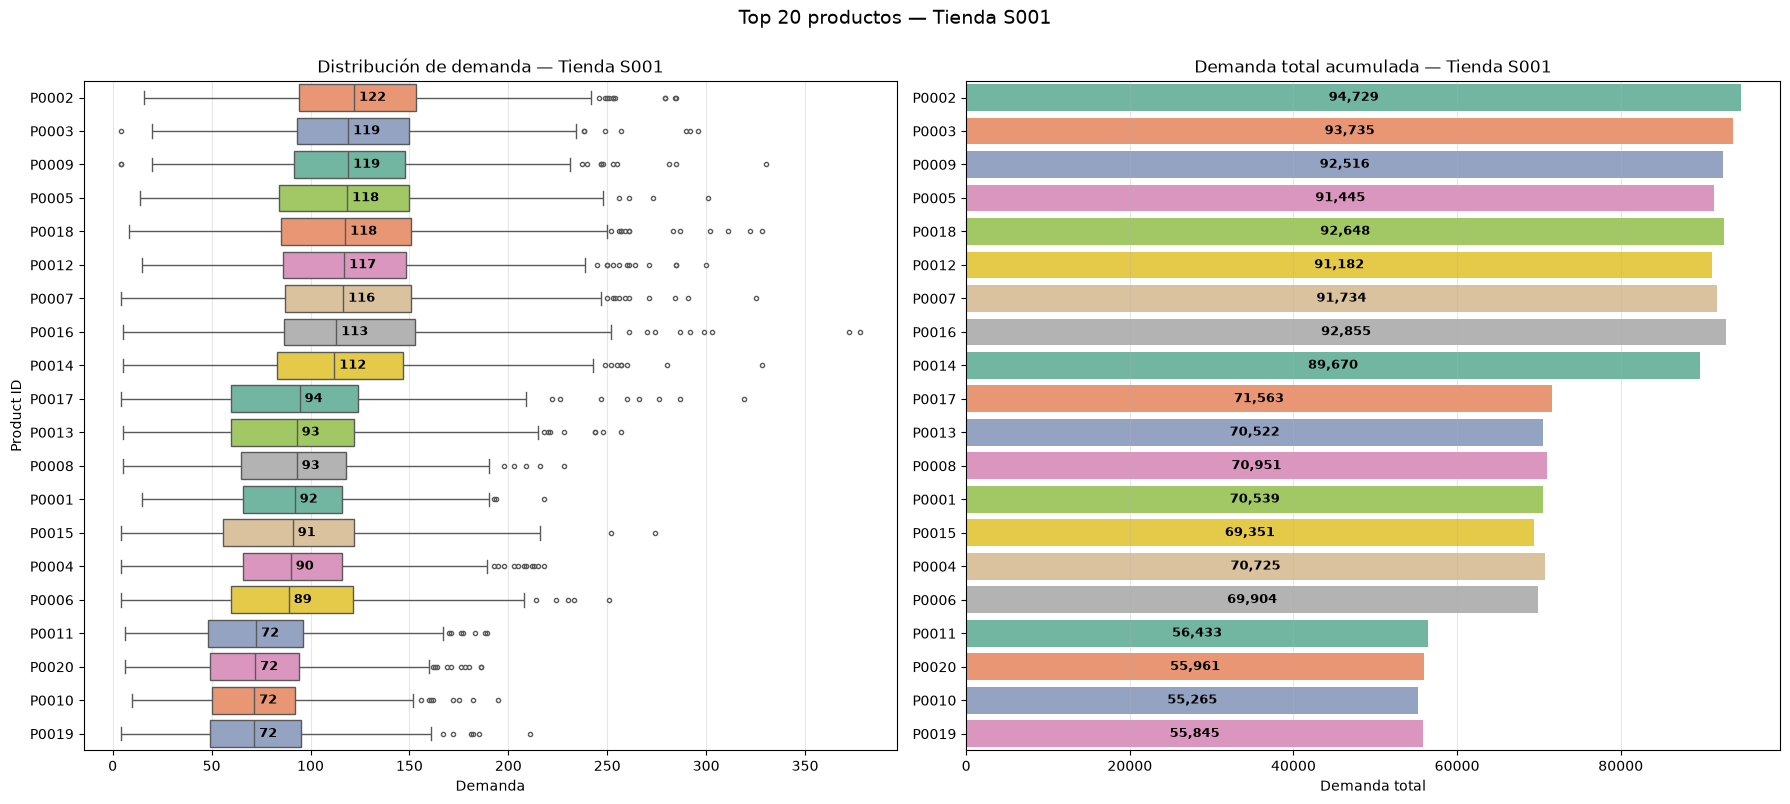

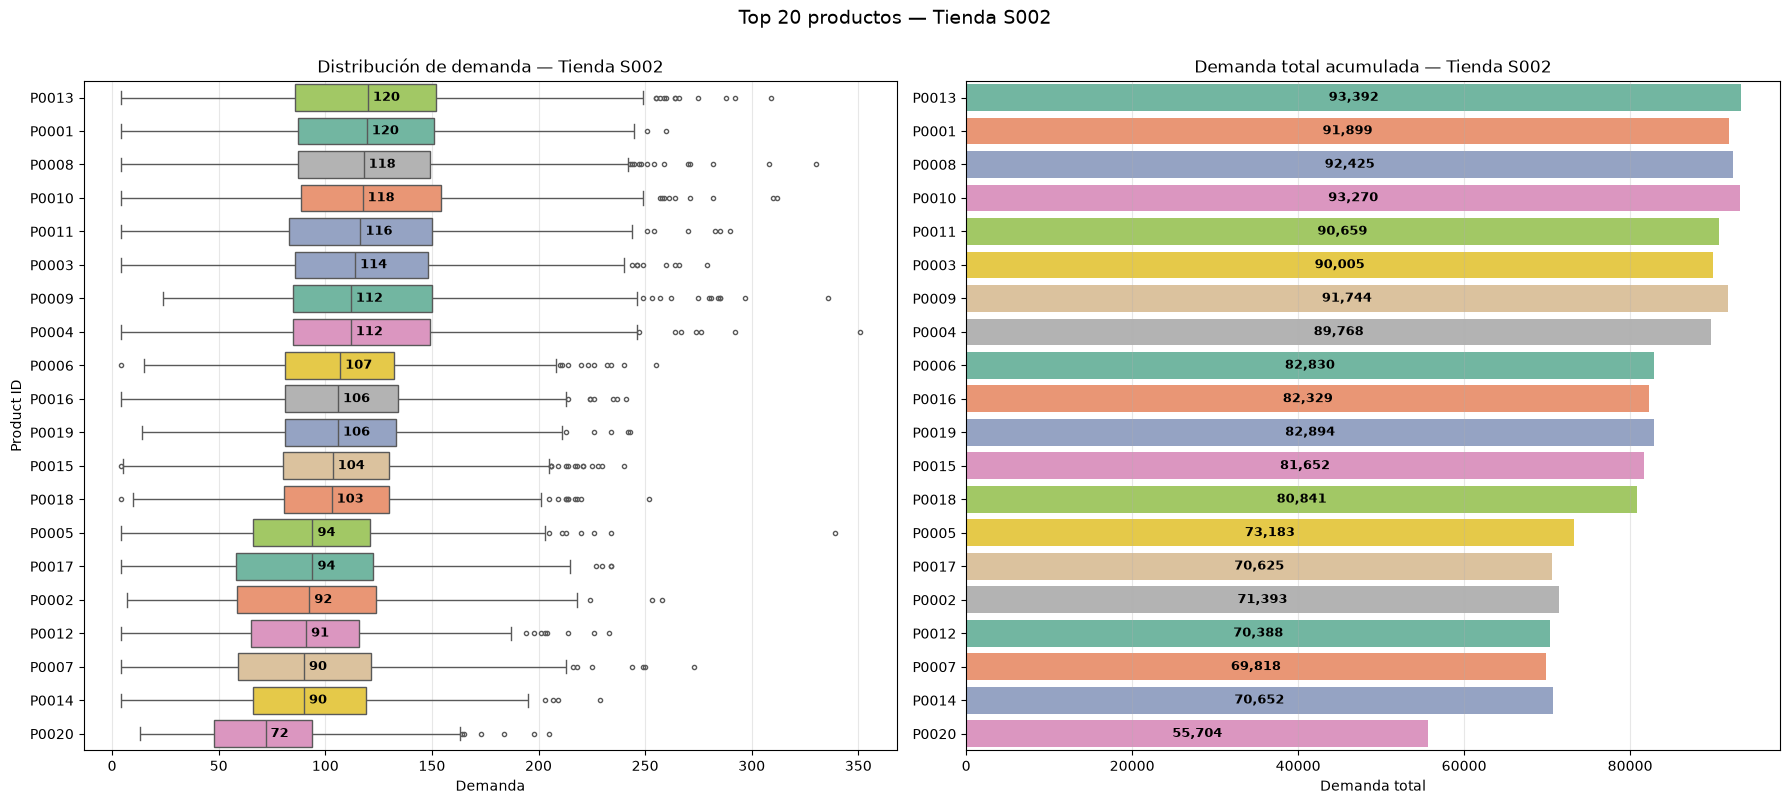

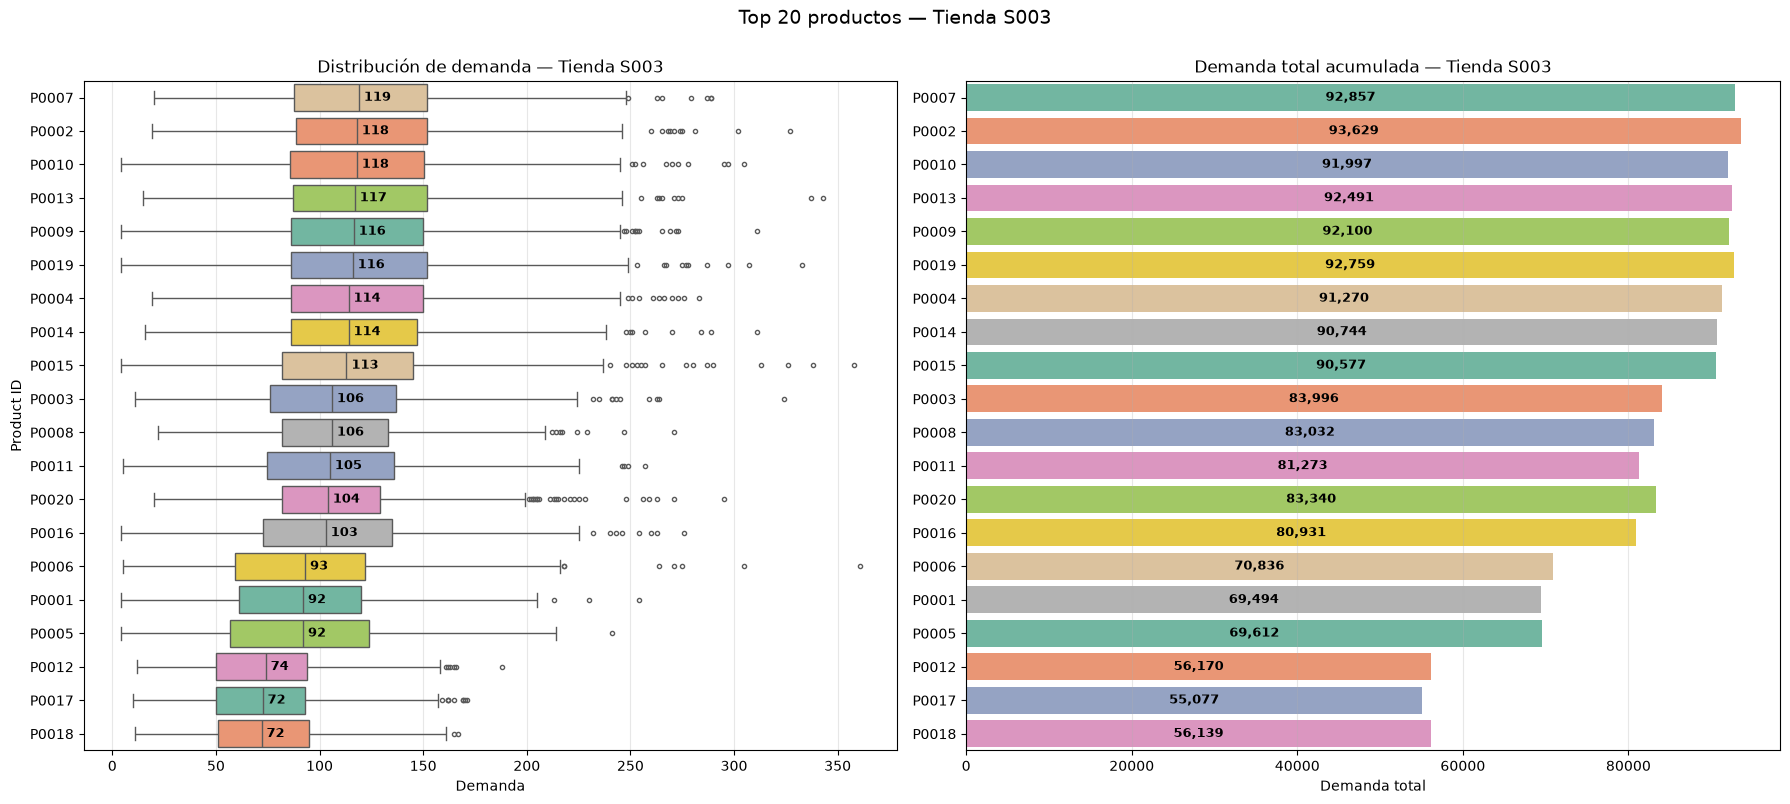

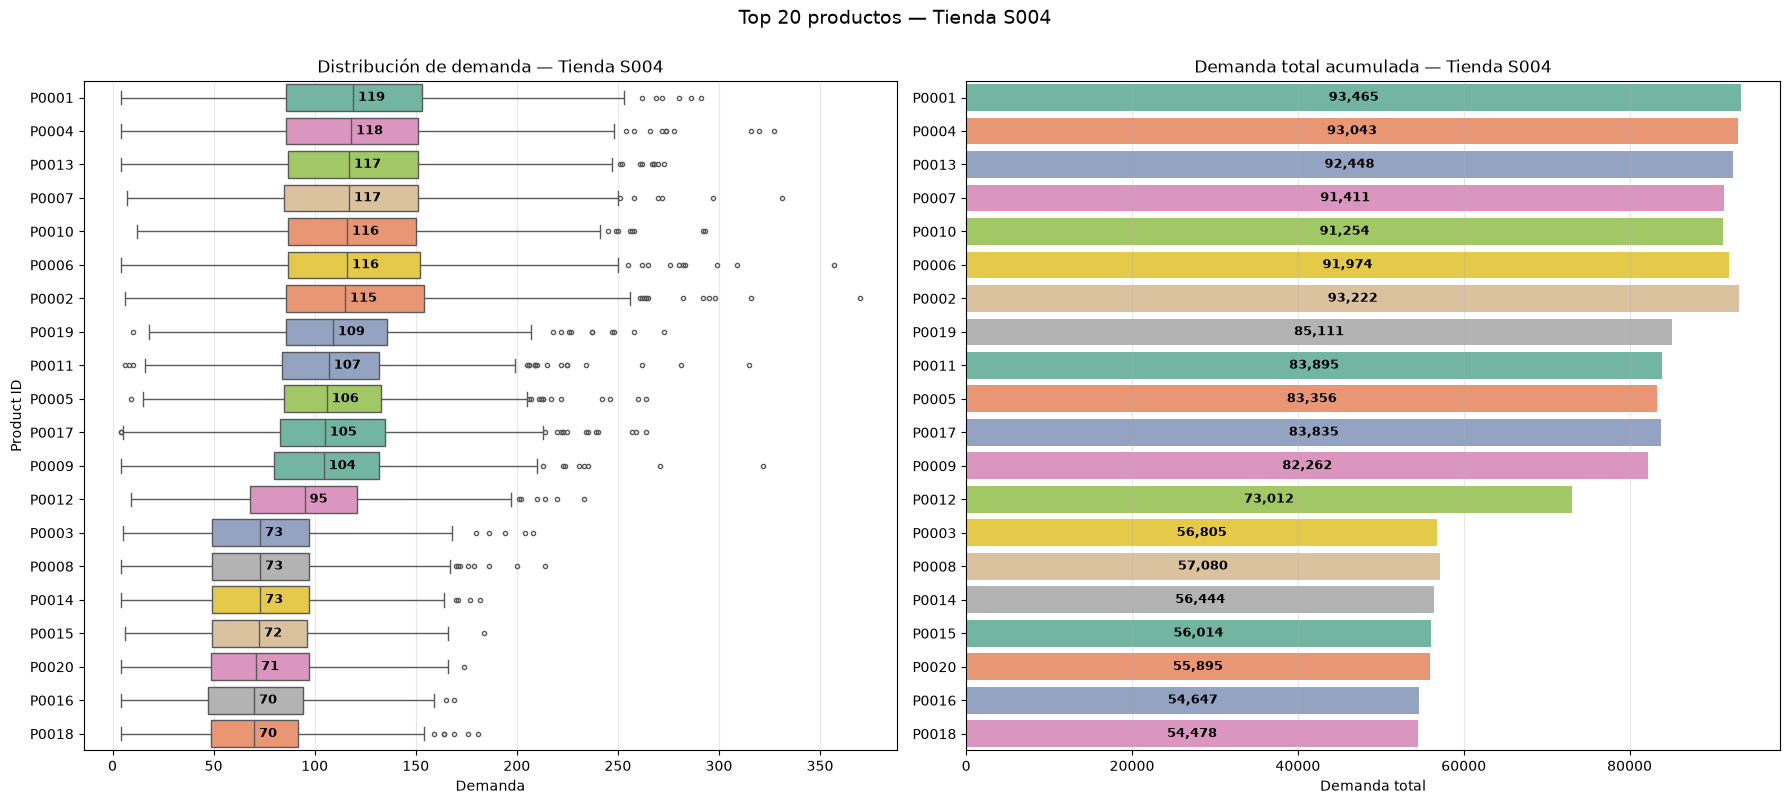

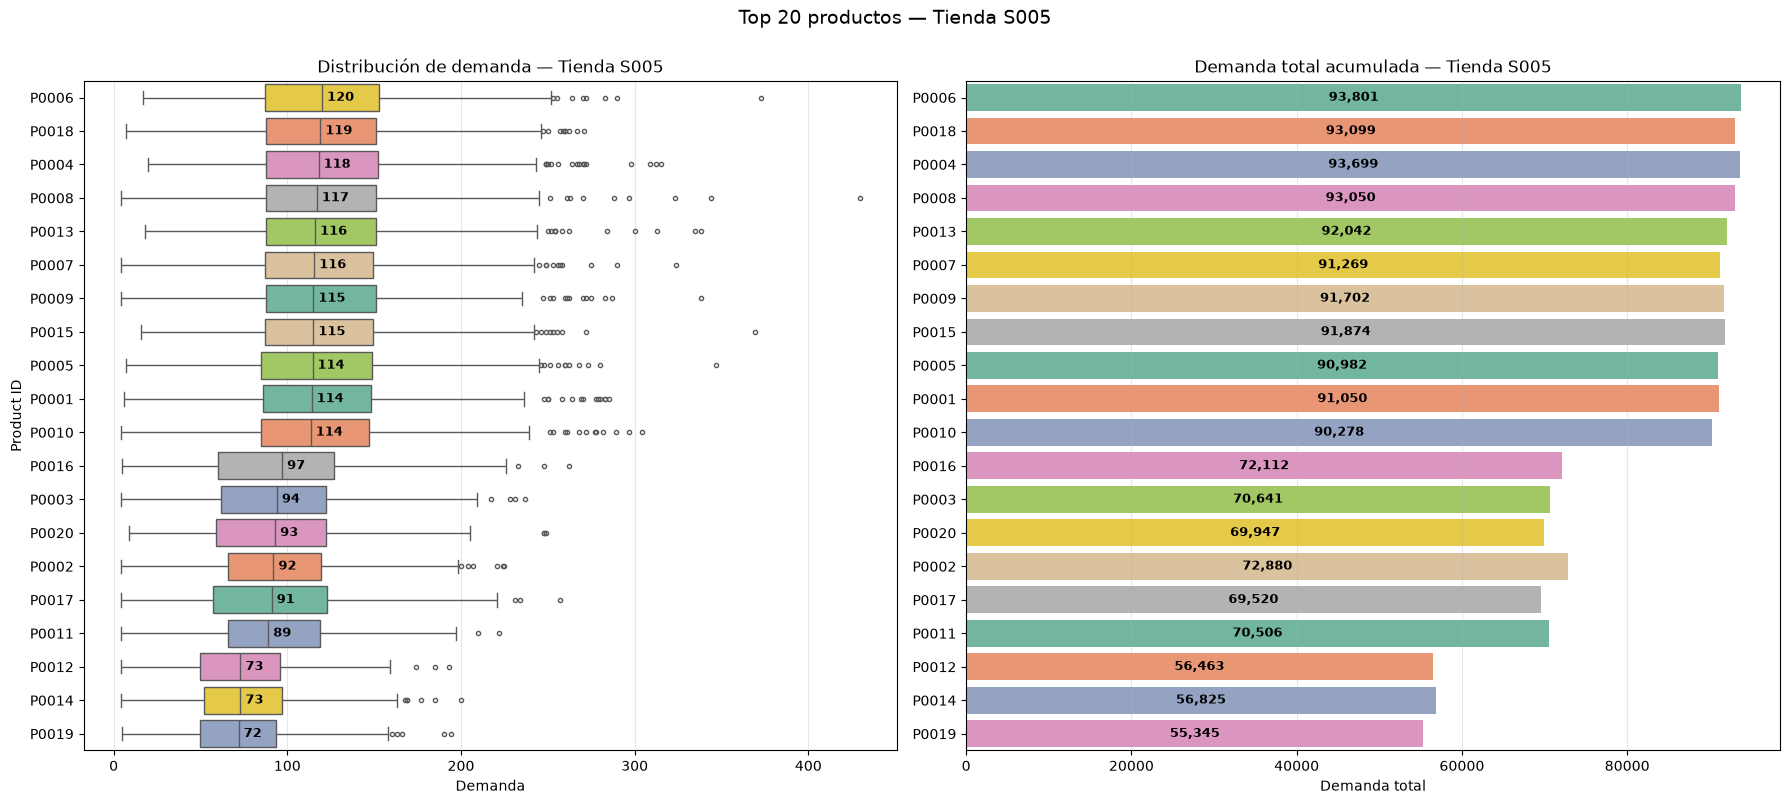

In [19]:
for store in sorted(df["store_id"].unique()):
    df_store = df[df["store_id"] == store]
    g_demand = df_store.groupby("product_id")["demand"]
    top20 = g_demand.median().sort_values(ascending=False).head(20).index
    df_top = df_store[df_store["product_id"].isin(top20)]

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Gráfico 1: Boxplot (4 líneas)
    sns.boxplot(data=df_top, x="demand", y="product_id", hue="product_id", palette="Set2", legend=False, order=top20, ax=axes[0], fliersize=3)
    axes[0].set(title=f"Distribución de demanda — Tienda {store}", xlabel="Demanda", ylabel="Product ID")
    axes[0].grid(axis="x", alpha=0.3)
    for i, (prod, med) in enumerate(g_demand.median().reindex(top20).items()):
        axes[0].text(med, i, f" {med:.0f}", va="center", ha="left", fontsize=9, fontweight="bold")

    # Gráfico 2: Barplot (4 líneas)
    tot_demand = g_demand.sum().reindex(top20)
    sns.barplot(x=tot_demand.values, y=tot_demand.index, hue=tot_demand.index, palette="Set2", legend=False, ax=axes[1])
    axes[1].set(title=f"Demanda total acumulada — Tienda {store}", xlabel="Demanda total", ylabel="", xlim=(0, tot_demand.max() * 1.05))
    axes[1].grid(axis="x", alpha=0.3)
    for i, val in enumerate(tot_demand.values):
        axes[1].text(val / 2, i, f"{val:,.0f}", va="center", ha="center", fontsize=9, fontweight="bold")

    plt.suptitle(f"Top 20 productos — Tienda {store}", fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

### 2.4 Análisis Temporal — Estacionalidad, Ciclos y Calendario

Evolución de la demanda agregada en el tiempo. Patrones anuales, mensuales y semanales.

Temporales

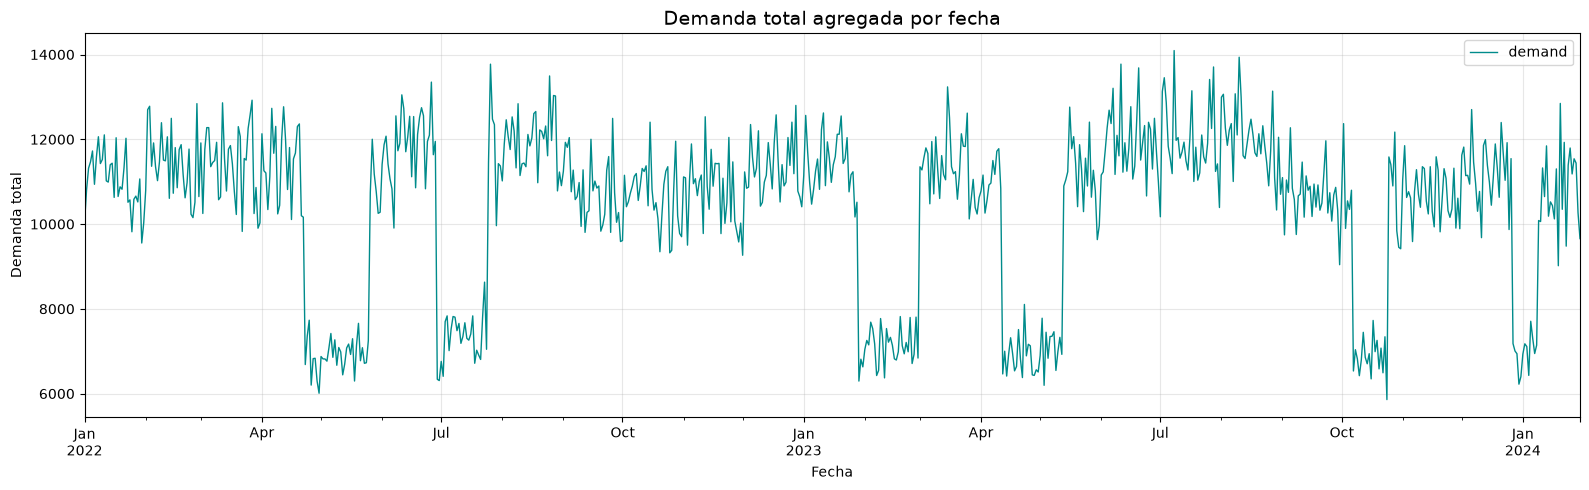

In [20]:
demand_diaria = df.groupby('date')['demand'].sum()

fig, ax = plt.subplots(figsize=(16, 5))
demand_diaria.plot(ax=ax, color='darkcyan', linewidth=1)

ax.set_title('Demanda total agregada por fecha', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Demanda total')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

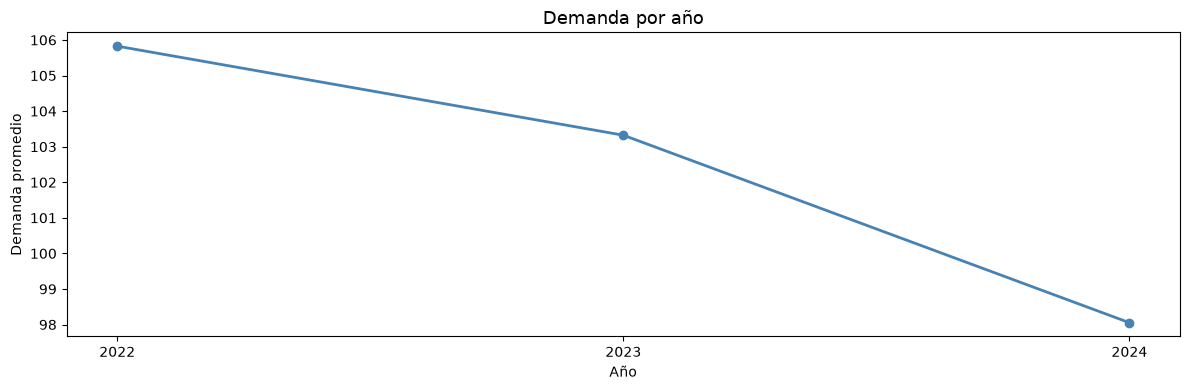

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))

year_stats = df.groupby('year')['demand'].mean().reset_index()
ax.plot(year_stats['year'], year_stats['demand'], marker='o', color='steelblue', linewidth=2)
ax.set_title('Demanda por año', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Demanda promedio')
ax.set_xticks(year_stats['year'])

plt.tight_layout()
plt.show()

C:\Users\Diego\AppData\Local\Temp\ipykernel_19016\1643857045.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dia_stats = df.groupby('day_of_week')['demand'].mean().reindex(orden_dias).reset_index()


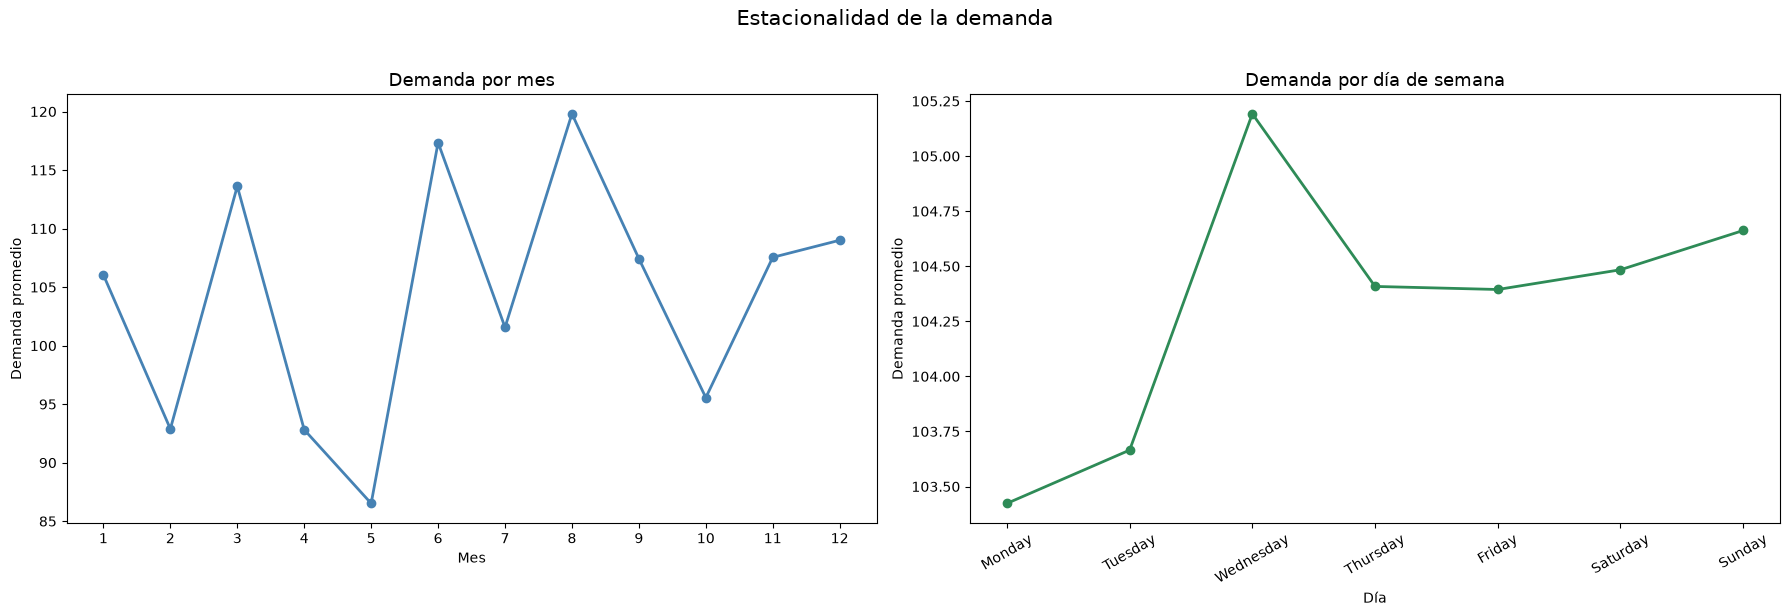

In [22]:
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
              'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Demanda por mes
mes_stats = df.groupby('month')['demand'].mean().reset_index()
axes[0].plot(mes_stats['month'], mes_stats['demand'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Demanda por mes', fontsize=13)
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Demanda promedio')
axes[0].set_xticks(mes_stats['month'])

# Demanda por día de semana
dia_stats = df.groupby('day_of_week')['demand'].mean().reindex(orden_dias).reset_index()
axes[1].plot(range(len(orden_dias)), dia_stats['demand'], marker='o', color='seagreen', linewidth=2)
axes[1].set_xticks(range(len(orden_dias)))
axes[1].set_xticklabels(orden_dias, rotation=30)
axes[1].set_title('Demanda por día de semana', fontsize=13)
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Demanda promedio')

plt.suptitle('Estacionalidad de la demanda', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# Guardar 
df.to_pickle('../Data/df_clean.pkl')